In [1]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from functools import partial
import scipy.io
from sklearn.model_selection import train_test_split
import time
import pickle
#import torch
import os

## DeepONet Class

In [2]:
class BranchNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        
        # #x has shape (ns, nx, ny) - so add channel dimension: (ns, nx, ny, nc)
        x = x[..., jnp.newaxis]

        #2D Convolutional layers and pooling layers
        x = nn.Conv(features = 32, kernel_size = (3,3,3), strides = (2,2,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.max_pool(x, window_shape=(2,2,2), strides = (2,2,2), padding = "SAME")

        x = nn.Conv(features = 32, kernel_size = (2,2,2), strides = (2,2,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape = (2,2,2), strides = (2,2,2), padding = "SAME")

        x = x.flatten()   #flattening layer
        for feat in self.features[:-1]:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        x = nn.Dense(self.features[-1])(x)
        return x

class TrunkNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        for feat in self.features:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        return x

class DeepONet(nn.Module):
    branch_features: list
    trunk_features: list
    
    def setup(self):
        self.branch_net = BranchNet(self.branch_features)
        self.trunk_net = TrunkNet(self.trunk_features)

    @nn.compact
    def __call__(self, branch_input, trunk_input):
        branch_out = jax.vmap(self.branch_net, in_axes = 0)(branch_input) 
        trunk_out = jax.vmap(self.trunk_net, in_axes = 0)(trunk_input)     
        output = jnp.einsum('bi,ti->bt', branch_out, trunk_out) 
        bias = self.param('bias', nn.initializers.zeros, (1,))
        output = output + bias
        return output

## Data Preparation

In [3]:
dataset = np.load('/home/dnayak2/scr4_sgoswam4/Dibya/backup/Datasets/3D_Heat_Conduction/processed/3d_heat_field_results.npz')

In [4]:
outputs = dataset['heat_field']
outputs = jnp.array(outputs)
outputs.shape

(1000, 101, 32, 32, 16)

In [5]:
del dataset

In [6]:
#outputs = outputs[:00]
nsamples = outputs.shape[0]
nx = outputs.shape[2]
ny = outputs.shape[3]
nz = outputs.shape[4]
nt = outputs.shape[1]
# outputs = jnp.nan_to_num(outputs,nan = 0.0)
# outputs_min, outputs_max = outputs.min(),outputs.max()
# outputs_scaled = (outputs-outputs_min)/(outputs_max-outputs_min)

In [7]:
outputs.min(),outputs.max()

(Array(0., dtype=float32), Array(0.9990419, dtype=float32))

In [8]:
train_time_step = 33

# Split into training and testing dataset
data_train,data_test = train_test_split(outputs,test_size = 0.2,
                                        shuffle = False,random_state = 42)

input_train = data_train[:,:train_time_step]
output_train = data_train[:,1:train_time_step+1]
print("Original Training Data Shape:",data_train.shape)
print("Original Test Data Shape:",data_test.shape)
print("Original Input Training Data Shape:",input_train.shape)
print("Original Output Training Data Shape:",output_train.shape)


# Reshape data
input_train = input_train.reshape(-1,nx,ny,nz)
output_train = output_train.reshape(-1,nx*ny*nz)
print("Reshaped Input Training Data Shape:",input_train.shape)
print("Reshaped Output Training Data Shape:",output_train.shape)

#Splitting into training and validation dataset
input_train,input_valid,output_train,output_valid = train_test_split(input_train,output_train,
                                                                     test_size = 0.2,
                                                                     shuffle = True,
                                                                     random_state = 42)

print("Reshaped Input Training Data Shape:",input_train.shape)
print("Reshaped Output Training Data Shape:",output_train.shape)


Original Training Data Shape: (800, 101, 32, 32, 16)
Original Test Data Shape: (200, 101, 32, 32, 16)
Original Input Training Data Shape: (800, 33, 32, 32, 16)
Original Output Training Data Shape: (800, 33, 32, 32, 16)
Reshaped Input Training Data Shape: (26400, 32, 32, 16)
Reshaped Output Training Data Shape: (26400, 16384)
Reshaped Input Training Data Shape: (21120, 32, 32, 16)
Reshaped Output Training Data Shape: (21120, 16384)


In [9]:
#Form branch and trunk inputs train
xspan = jnp.linspace(0, 1, nx)
yspan = jnp.linspace(0, 1, ny)
zspan = jnp.linspace(0, 1, nz)
#Create for trunk network - a meshgrid of only spatial coordinates
[x,y,z] = jnp.meshgrid(xspan, yspan,zspan, indexing = 'ij')
grid = jnp.transpose(jnp.array([x.flatten(), y.flatten(),z.flatten()]))
print("Trunk Shape:",grid.shape)

Trunk Shape: (16384, 3)


In [10]:
# Branch and trunk data
branch_train = input_train
trunk_train = grid
don_train = output_train

print("Branch Training Data Shape:",branch_train.shape)
print("Trunk Training Data Shape:",trunk_train.shape)
print("DON Training Data Shape:",don_train.shape)

branch_valid = input_valid
trunk_valid = grid
don_valid = output_valid
print("Branch Validation Data Shape:",branch_valid.shape)
print("Trunk Validation Data Shape:",trunk_valid.shape)
print("DON Validation Data Shape:",don_valid.shape)

Branch Training Data Shape: (21120, 32, 32, 16)
Trunk Training Data Shape: (16384, 3)
DON Training Data Shape: (21120, 16384)
Branch Validation Data Shape: (5280, 32, 32, 16)
Trunk Validation Data Shape: (16384, 3)
DON Validation Data Shape: (5280, 16384)


In [11]:
key = jax.random.PRNGKey(42)

## Utility Functions


In [12]:
# Mean squared error loss function
@jax.jit
def loss_fn(params, branch_x, trunk_x, true_y):
    bs = branch_x.shape[0]
    loss = jnp.zeros((bs,nx,ny,nz))
    pred_y = model_jit(params,branch_x,trunk_x)
    pred_y = pred_y.reshape(-1,nx,ny,nz)
    true_y = true_y.reshape(-1,nx,ny,nz)
    loss1 = pred_y[:,:nx//2,:ny//2,:]-true_y[:,:nx//2,:ny//2,:] 
    loss2 = pred_y[:,:nx//2,ny//2:,:]-true_y[:,:nx//2,ny//2:,:]
    loss3 = pred_y[:,nx//2:,:ny//2,:]-true_y[:,nx//2:,:ny//2,:]
    loss4 = pred_y[:,nx//2:,ny//2:,:]
    #loss = jnp.mean((pred_y - true_y) ** 2)
    
    loss = jnp.mean(loss1**2+loss2**2+loss3**2)
    
    l2_error1 = jnp.linalg.norm(pred_y[:,:nx//2,:ny//2,:]-true_y[:,:nx//2,:ny//2,:])/\
                jnp.linalg.norm(true_y[:,:nx//2,:ny//2,:])
    l2_error2 = jnp.linalg.norm(pred_y[:,:nx//2,ny//2:,:]-true_y[:,:nx//2,ny//2:,:])/\
            jnp.linalg.norm(true_y[:,:nx//2,ny//2:,:])
    l2_error3 = jnp.linalg.norm(pred_y[:,nx//2:,:ny//2,:]-true_y[:,nx//2:,:ny//2,:])/\
        jnp.linalg.norm(true_y[:,nx//2:,:ny//2,:])
    
    return loss,[l2_error1,l2_error2,l2_error3]

In [13]:
# Updating each state
@jax.jit
def train_step(state, branch_x, trunk_x, true_y):
    (loss,_), grads = jax.value_and_grad(loss_fn,
                                        has_aux = True)(state.params, branch_x, trunk_x, true_y)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [22]:
# 4th order Runge-Kutta method
@jax.jit
def RK4(params,branch_x,trunk_x):
    dt = 0.01
    curr_state = branch_x
    k1 = model_jit(params,curr_state,trunk_x)
    k1 = k1.reshape(k1.shape[0],nx,ny,nz)
    k2 = model_jit(params,curr_state+0.5*dt*k1,trunk_x)
    k2 = k2.reshape(k2.shape[0],nx,ny,nz)
    k3 = model_jit(params,curr_state+0.5*dt*k2,trunk_x)
    k3 = k3.reshape(k3.shape[0],nx,ny,nz)
    k4 = model_jit(params,curr_state+dt*k3,trunk_x)
    k4 = k4.reshape(k4.shape[0],nx,ny,nz)
    next_state = curr_state+(dt/6)*(k1+2*k2+2*k3+k4)
    next_state = next_state.reshape(next_state.shape[0],nx*ny*nz)
    return next_state

## Model Initialization

In [14]:
branch_train[0:1].shape, trunk_train.shape

((1, 32, 32, 16), (16384, 3))

In [15]:
# Create the model
p = 100
branch_features = [256,128]+[p]
trunk_features = [128]*4+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)
model_jit = jax.jit(model.apply)
# Initialize model
params = model.init(key, branch_train[0:1], trunk_train[0:1])
lr_scheduler = optax.schedules.exponential_decay(1e-3, 2000, 0.96)
optimizer = optax.adam(learning_rate = lr_scheduler)
state = train_state.TrainState.create(apply_fn=model_jit,params=params,tx=optimizer)

## Training

In [16]:
train_loss = []
valid_loss = []
batch_size = 32
min_loss = jnp.inf

In [17]:
# Training the model
from tqdm import tqdm
n_epochs = int(1e5)
#st = time.time()
for epoch in tqdm(range(n_epochs), desc="Training Progress"):
    #print(epoch)
    shuffled_idx = jax.random.permutation(jax.random.PRNGKey(epoch), branch_train.shape[0])
    shuffled_idx = shuffled_idx[:batch_size]
    branch_x = branch_train[shuffled_idx]
    true_y = don_train[shuffled_idx]
    trunk_x = trunk_train
    
    state,tloss = train_step(state, branch_x, trunk_x, true_y)      
        
    vloss,[l2_error1,l2_error2,l2_error3] = loss_fn(state.params,branch_valid,trunk_valid,don_valid)
    
    if (epoch) % 1000 == 0:
        print(f"Epoch {epoch}| Train_Loss:{tloss}| Valid_Loss:{vloss}| " 
              f"L2_error:{l2_error1},{l2_error2},{l2_error3}")
        if vloss<min_loss: 
            min_loss = vloss 
            with open("ar_3d_heat.pkl", "wb") as f:
                pickle.dump(state.params, f)
            
        
    train_loss.append(tloss)
    valid_loss.append(vloss)
# et = time.time()
# print("Final Training Time: "+str(et-st))

Training Progress:   0%|          | 11/100000 [00:19<34:45:17,  1.25s/it]

Epoch 0| Train_Loss:0.05330352857708931| Valid_Loss:0.35795503854751587| L2_error:1.6642310619354248,21.376920700073242,22.241451263427734


Training Progress:   1%|          | 1012/100000 [00:31<21:38, 76.23it/s] 

Epoch 1000| Train_Loss:0.003552138339728117| Valid_Loss:0.004408482927829027| L2_error:0.3956829607486725,1.057018756866455,0.9981751441955566


Training Progress:   2%|▏         | 2012/100000 [00:43<19:56, 81.87it/s]

...

Training Progress:  98%|█████████▊| 98012/100000 [20:18<00:24, 82.19it/s]

Epoch 98000| Train_Loss:4.11132350564003e-06| Valid_Loss:5.3690873755840585e-06| L2_error:0.011743037961423397,0.05049381032586098,0.06419398635625839


Training Progress:  99%|█████████▉| 99012/100000 [20:30<00:12, 82.02it/s]

Epoch 99000| Train_Loss:4.127521606278606e-06| Valid_Loss:5.477092145156348e-06| L2_error:0.012525506317615509,0.05173752084374428,0.05380915105342865


Training Progress: 100%|██████████| 100000/100000 [20:43<00:00, 80.45it/s]


In [18]:
# Function to plot loss
def loss_plot(ax,loss_arr,loss_type:str,n_steps = 1000):
    loss_arr = jnp.array(loss_arr)
    loss = loss_arr[::n_steps]
    epochs = jnp.arange(0,loss_arr.shape[0],n_steps)
    ax.semilogy(epochs, loss, label=loss_type)
    ax.set_xlabel("# Epochs",fontsize = 14)
    ax.set_ylabel("Loss",fontsize = 14)
    ax.legend()
    ax.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
    ax.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
    ax.minorticks_on()

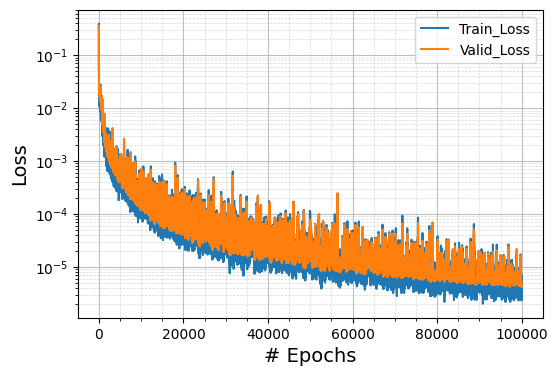

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
loss_plot(ax,train_loss,'Train_Loss',1)
loss_plot(ax,valid_loss,'Valid_Loss',1)

In [ ]:
fig.savefig("loss_heat_3d_ar.png",dpi=300)

## Inference

In [34]:
# Uploading the best optimized parameters
with open("ar_3d_heat.pkl", "rb") as f:
    params = pickle.load(f)
p = 100
branch_features = [256,128]+[p]
trunk_features = [128]*4+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)
model_jit = jax.jit(model.apply)

In [48]:
test_sample = jnp.arange(0,outputs.shape[0])
ns = len(test_sample)
# X = grid
u_test = outputs[test_sample]
branch_test = outputs[test_sample,0].reshape(-1,nx,ny,nz)
trunk_test = grid

In [51]:
# Using DeepONet+RK4 to predict 

u_pred = jnp.zeros((ns,nt,nx,ny,nz))
u_pred = u_pred.at[:, 0, :,:,:].set(branch_test)
for i in range(1, nt):
    umodel = model_jit(params,branch_test,trunk_test) #Shape: Ns,Nc
    #print(umodel.shape)
    branch_test = umodel.reshape(-1,nx,ny,nz)
    branch_test = branch_test.at[:,nx//2:,ny//2:,:].set(0.0)
    u_pred = u_pred.at[:, i, :,:,:].set(branch_test)

In [52]:
#u_test = data_test[0:3,:,:]
u_pred.shape,branch_test.shape,u_test.shape

((1000, 101, 32, 32, 16), (1000, 32, 32, 16), (1000, 101, 32, 32, 16))

In [57]:
np.savez_compressed("u_pred_auto_3dheat.npz",u_pred)

In [55]:
err1 = np.linalg.norm(u_pred[:,:,:nx//2,:ny//2,:] - u_test[:,:,:nx//2,:ny//2,:])/np.linalg.norm(u_test[:,:,:nx//2,:ny//2,:])
err2 = np.linalg.norm(u_pred[:,:,:nx//2,ny//2:,:] - u_test[:,:,:nx//2,ny//2:,:])/np.linalg.norm(u_test[:,:,:nx//2,ny//2:,:])
err3 = np.linalg.norm(u_pred[:,:,nx//2:,:ny//2,:] - u_test[:,:,nx//2:,:ny//2,:])/np.linalg.norm(u_test[:,:,nx//2:,:ny//2,:])

# np.linalg.norm(u_pred - u_test)/np.linalg.norm(u_test)
print(err1,err2,err3)

2.9785175 2.5213025 2.0560975


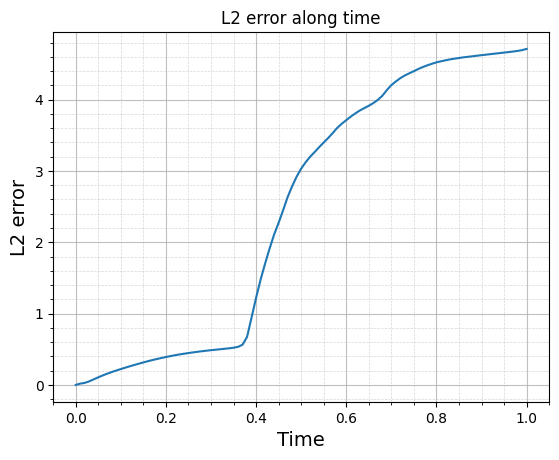

In [56]:
# Plot of L2 error for each time step
l2_error = []
for i in range(nt):
    l2_error.append(np.linalg.norm(u_pred[:,i,:,:,:] - u_test[:,i,:,:,:])/np.linalg.norm(u_test[:,i,:,:,:]))
plt.plot(jnp.linspace(0,1,nt),jnp.array(l2_error))
plt.xlabel("Time",fontsize = 14)
plt.ylabel("L2 error",fontsize = 14)
plt.title("L2 error along time")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

In [ ]:
def visualize_solution(solution, domain, time_steps=None, show_plot=True):
    nt, nx, ny, nz = solution.shape
    
    if time_steps is None:
        time_steps = [0, nt//2, nt-1]
    
    n_times = len(time_steps)
    fig = plt.figure(figsize=(5*n_times, 12))
    
    # Middle slices
    z_mid = nz // 2
    y_mid = ny // 2
    x_mid = nx // 2
    
    # Get global min/max for consistent color scale
    vmin = np.min(solution[:, domain])
    vmax = np.max(solution[:, domain])
    
    for idx, t in enumerate(time_steps):
        # XY plane (z slice)
        ax1 = fig.add_subplot(3, n_times, idx + 1)
        data = solution[t, :, :, z_mid].copy()
        data[~domain[:, :, z_mid]] = np.nan
        # im1 = ax1.imshow(data.T, origin='lower', cmap='jet', interpolation='bilinear',
        #                  vmin=vmin, vmax=vmax)
        im1 = ax1.imshow(data.T, origin='lower', cmap='jet', interpolation='bilinear')
        ax1.set_title(f'XY plane, t={t}')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        plt.colorbar(im1, ax=ax1, label='Temperature')
        
        # YZ plane (x slice)
        ax2 = fig.add_subplot(3, n_times, n_times + idx + 1)
        data = solution[t, x_mid, :, :].copy()
        data[~domain[x_mid, :, :]] = np.nan
        # im2 = ax2.imshow(data.T, origin='lower', cmap='jet', interpolation='bilinear',
        #                  vmin=vmin, vmax=vmax)
        im2 = ax2.imshow(data.T, origin='lower', cmap='jet', interpolation='bilinear')
        ax2.set_title(f'YZ plane, t={t}')
        ax2.set_xlabel('Y')
        ax2.set_ylabel('Z')
        plt.colorbar(im2, ax=ax2, label='Temperature')
        
        # ZX plane (y slice)
        ax3 = fig.add_subplot(3, n_times, 2*n_times + idx + 1)
        data = solution[t, :, y_mid, :].copy()
        data[~domain[:, y_mid, :]] = np.nan
        # im3 = ax3.imshow(data.T, origin='lower', cmap='jet', interpolation='bilinear',
        #                  vmin=vmin, vmax=vmax)
        im3 = ax3.imshow(data.T, origin='lower', cmap='jet', interpolation='bilinear')
        ax3.set_title(f'ZX plane, t={t}')
        ax3.set_xlabel('X')
        ax3.set_ylabel('Z')
        plt.colorbar(im3, ax=ax3, label='Temperature')
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    else:
        plt.close()
    
    # Clear data
    del data
    #gc.collect()


In [ ]:
def create_l_shaped_domain(nx, ny, nz):
    # Create full box
    domain = np.ones((nx, ny, nz), dtype=bool)
    
    # Remove upper-right corner to create L-shape
    # Remove the region where x >= nx//2 and y >= ny//2
    cut_x = nx // 2
    cut_y = ny // 2
    domain[cut_x:, cut_y:, :] = False
    
    # Identify boundary nodes (external boundaries AND internal cut edges)
    boundary = np.zeros((nx, ny, nz), dtype=bool)
    
    for i in range(nx):
        for j in range(ny):
            for k in range(nz):
                if domain[i, j, k]:
                    # Check if on the external edge of the grid
                    if i == 0 or j == 0 or k == 0 or k == nz-1:
                        boundary[i, j, k] = True
                    # Check if on the outer edges (not the cut edges)
                    elif (i == nx-1 and j < cut_y) or (j == ny-1 and i < cut_x):
                        boundary[i, j, k] = True
                    # Check if adjacent to removed region (internal boundary)
                    elif (i+1 < nx and not domain[i+1, j, k]) or \
                         (j+1 < ny and not domain[i, j+1, k]):
                        boundary[i, j, k] = True
    
    # Interior nodes are domain nodes that are not boundary nodes
    interior = domain & (~boundary)
    
    return domain, boundary, interior


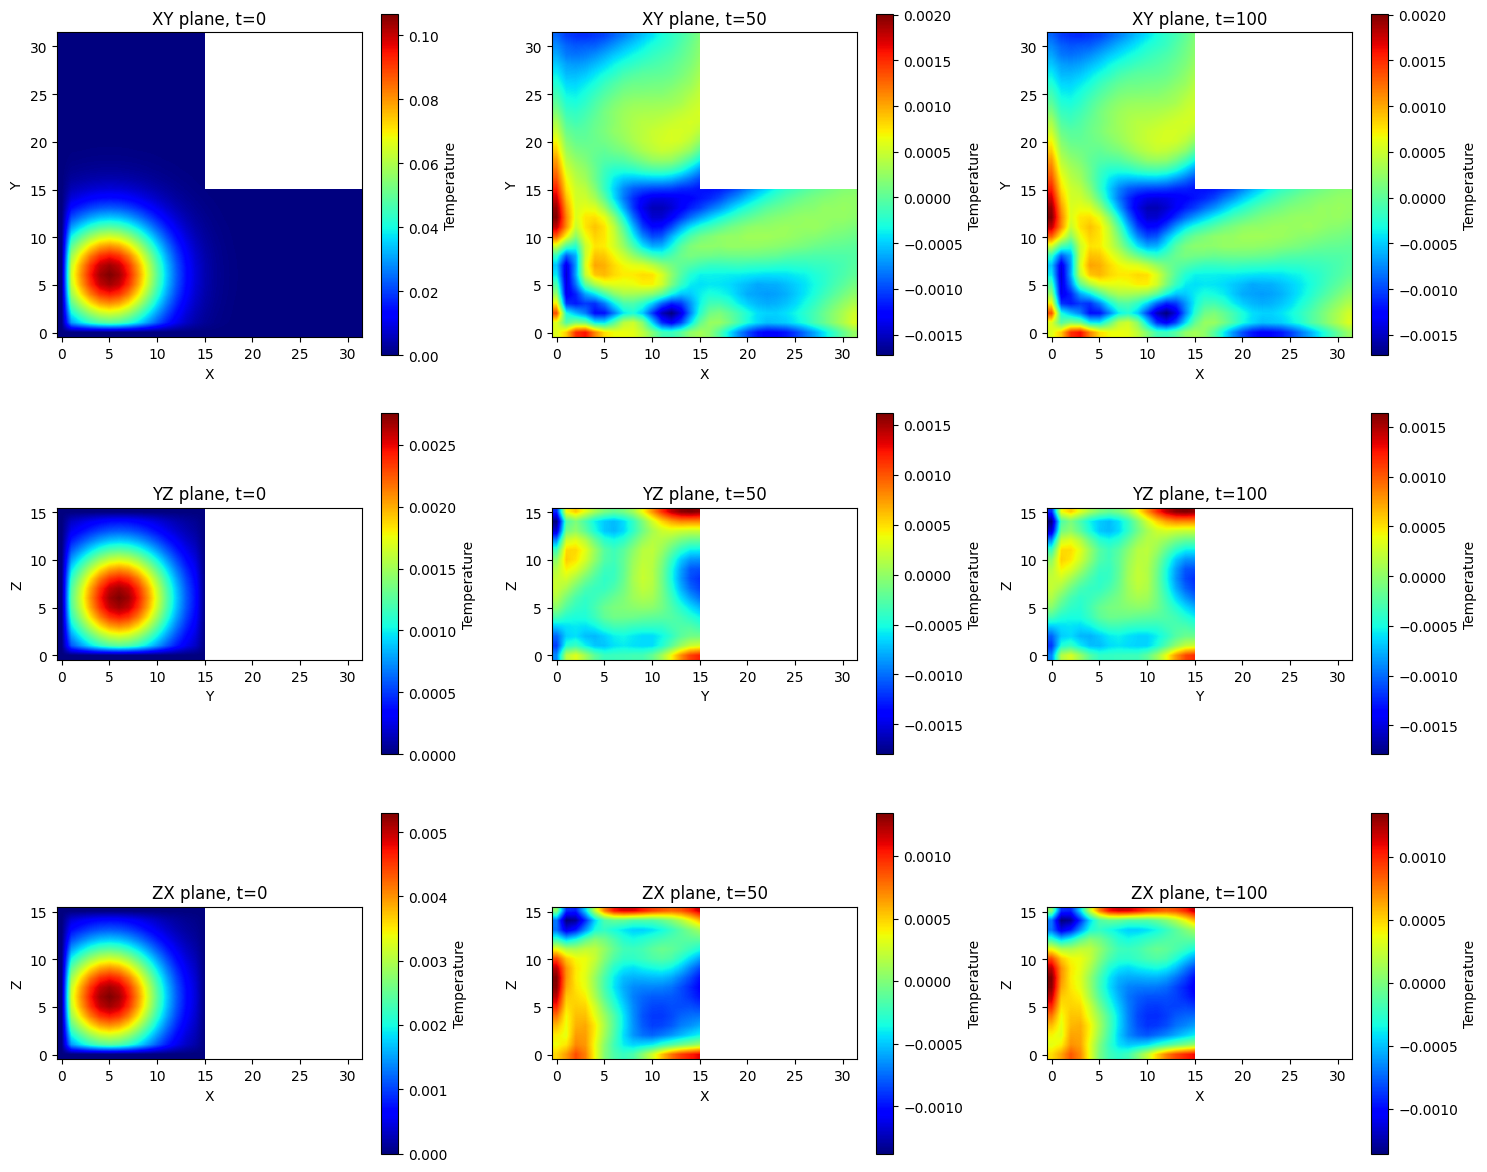

In [32]:
# Predicted Result
u_pred_np = np.array(u_pred)
domain, boundary, interior = create_l_shaped_domain(nx, ny, nz)
visualize_solution(u_pred_np[0], domain, time_steps=[0, nt//2, nt-1], show_plot=True)

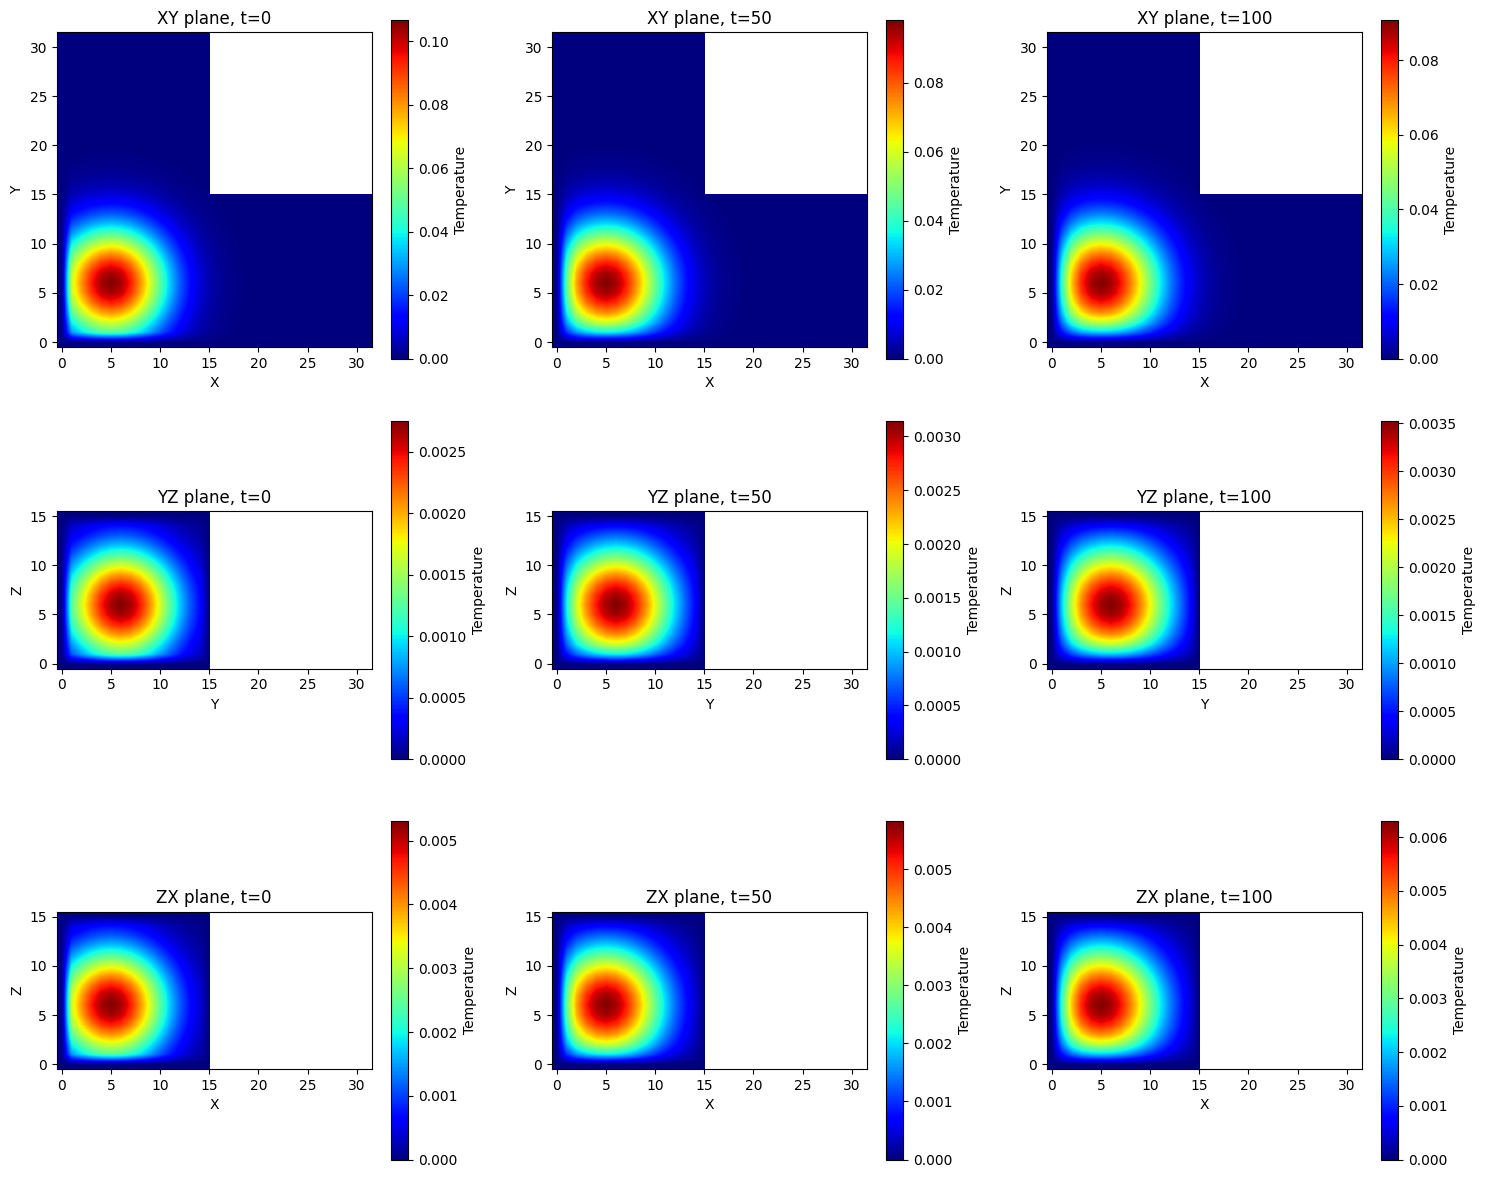

In [48]:
# Actual Result
u_test_np = np.array(u_test)
domain, boundary, interior = create_l_shaped_domain(nx, ny, nz)
visualize_solution(u_test_np[0], domain, time_steps=[0, nt//2, nt-1], show_plot=True)

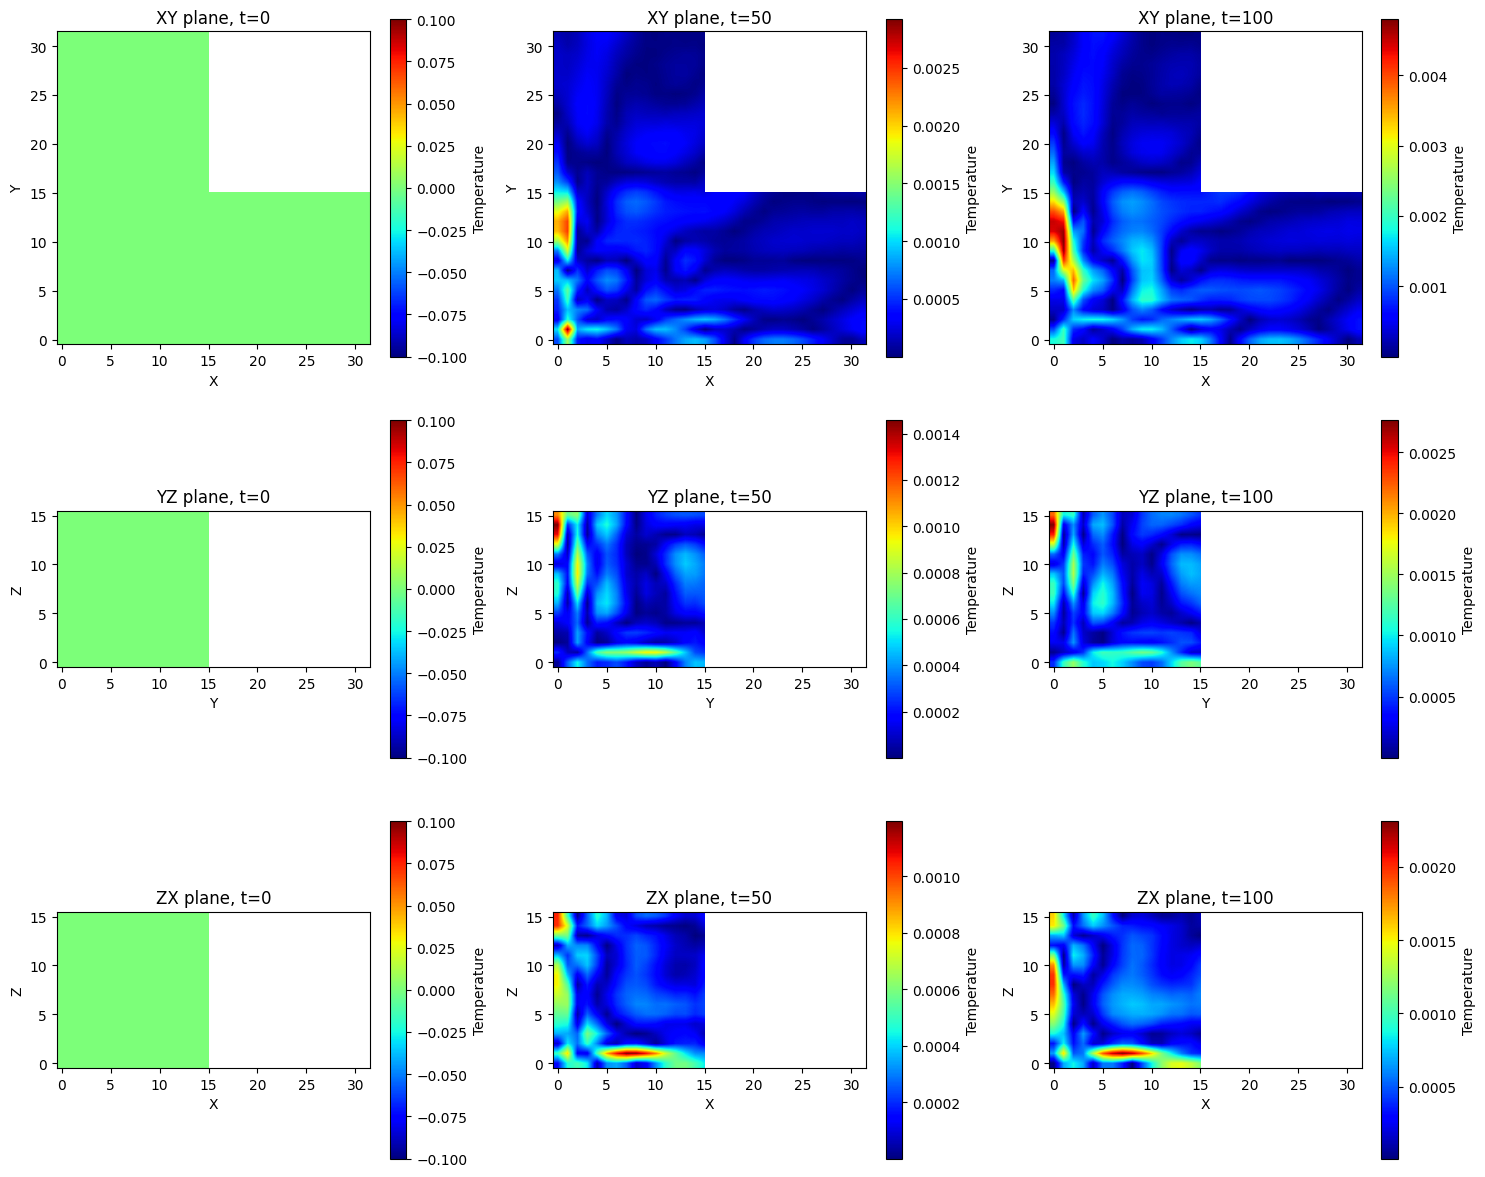

In [49]:
# Abs Error
u_err_np = np.array(abs(u_test-u_pred))
domain, boundary, interior = create_l_shaped_domain(nx, ny, nz)
visualize_solution(u_err_np[0], domain, time_steps=[0, nt//2, nt-1], show_plot=True)